# Analisis Exploratorio de Datos (EDA): Descomposicion Paso a Paso (NLP + Metricas Relativas)

## Contexto y Objetivo del EDA
Los eventos gestionados en **TuBoleta** presentan una alta heterogeneidad en la denominacion de localidades (*VIP, General, Platino, Palcos, Platea, Occidental, Oriental, etc.*), las cuales cambian segun el recinto (*venue*) y el promotor.

En este cuaderno exploramos y validamos **cada funcion de forma individual y desacoplada** para analizar sus entradas, salidas y transformaciones intermedias:
1. **Modulo 1 - NLP Individual (`src.nlp_utils`)**:
   - `normalizar_texto()`: Estandarizacion de mayusculas, acentos Unicode y espacios.
   - `STOPWORDS_MARKETING` y `limpiar_ruido_marketing()`: Supresion de marcas, patrocinios, nombres de gira y rangos numericos.
   - `extraer_atributos_estructurales()`: Extraccion de 17 variables binarias en 4 dimensiones ortogonales.
   - `vectorizar_texto_limpio()`: Extraccion de n-gramas TF-IDF sobre el texto limpio.
2. **Modulo 2 - Metricas Relativas Individual (`src.feature_engineering`)**:
   - `filtrar_consistencia_localidades()`: Reglas de validacion fisica de aforos y montos.
   - `calcular_metricas_relativas()`: Calculo de ratios de precio, peso de aforo y ocupacion por evento.
3. **Analisis Exploratorio, Correlaciones y Visualizaciones**: Evaluacion de los 4 cuadrantes de demanda con analisis detallado y 3 conclusiones por grafico.

## 1. Configuracion del Entorno e Importacion de Funciones Desacopladas

In [1]:
import os
import sys
sys.path.append("../")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importacion de funciones atomicas individuales de src/
from src.nlp_utils import (
    normalizar_texto,
    STOPWORDS_MARKETING,
    limpiar_ruido_marketing,
    extraer_atributos_estructurales,
    vectorizar_texto_limpio
)
from src.feature_engineering import (
    filtrar_consistencia_localidades,
    calcular_metricas_relativas
)

# Configuracion grafica general
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
sns.set_palette("viridis")

print("Funciones individuales cargadas exitosamente.")

Funciones individuales cargadas exitosamente.


## 2. Carga y Exploracion Inicial del Dataset Raw
Cargamos el archivo Parquet original y analizamos la cardinalidad y estructura inicial.

In [2]:
data_path = "../data/raw/localidades_eda.parquet" if os.path.exists("../data/raw/localidades_eda.parquet") else "data/raw/localidades_eda.parquet"
df_raw = pd.read_parquet(data_path)

print(f"Dimensiones iniciales: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas")
print(f"Total de eventos unicos (t_performance_id): {df_raw['t_performance_id'].nunique():,}")
print(f"Total de nombres unicos de localidad: {df_raw['logical_seat_category'].nunique():,}")
display(df_raw.head(4))

Dimensiones iniciales: 34,030 filas x 19 columnas
Total de eventos unicos (t_performance_id): 18,650
Total de nombres unicos de localidad: 2,401


,t_performance_id,t_product_id,product_code,product,product_family,product_date,site,t_site_id,performance_quota,logical_seat_category,dn_quota,ave_unit_amt_itx,ave_total_unit_amt_itx,ave_base_unit_amt_itx,med_unit_amt_itx,med_total_unit_amt_itx,med_base_unit_amt_itx,net_sold_p_qty,net_sold_c_qty
0,10229388062639,10229391547237,BECKARO2,MAÑANA SERÁ BONITO LATAM TOUR KAROL G - 2DA FECHA,EVENTO,2024-04-06,ESTADIO EL CAMPIN,101326133646,46678,ORIENTAL BAJA,11719,369473.684211,1.023158e+06,227368.421053,405000.0,810000.0,405000.0,84.0,26.0
1,10229388062639,10229391547237,BECKARO2,MAÑANA SERÁ BONITO LATAM TOUR KAROL G - 2DA FECHA,EVENTO,2024-04-06,ESTADIO EL CAMPIN,101326133646,46678,PREFERENCIAL,10000,426637.931034,2.263793e+06,235086.206897,505000.0,1010000.0,505000.0,232.0,190.0
2,10229388062639,10229391547237,BECKARO2,MAÑANA SERÁ BONITO LATAM TOUR KAROL G - 2DA FECHA,EVENTO,2024-04-06,ESTADIO EL CAMPIN,101326133646,46678,VIP OCCIDENTAL,4080,609869.565217,2.329261e+06,374739.130435,845000.0,845000.0,845000.0,232.0,328.0
3,10229388062639,10229391547237,BECKARO2,MAÑANA SERÁ BONITO LATAM TOUR KAROL G - 2DA FECHA,EVENTO,2024-04-06,ESTADIO EL CAMPIN,101326133646,46678,NORTE ALTA,3001,120952.380952,5.785556e+05,84666.666667,127000.0,381000.0,127000.0,168.0,102.0


## 3. Modulo NLP Paso a Paso (`src.nlp_utils`)

### Paso 3.1: Funcion `normalizar_texto(texto)`
- Convierte a mayusculas.
- Remueve acentos y tildes mediante descomposicion Unicode NFD.
- Elimina espacios multiples redundantes.

In [3]:
# Ejecutar normalizar_texto sobre una muestra diversa
muestras_texto = [
    "  Balcón  Segundo Piso  ",
    "PLAZA DE TOROS - PALCOS VIP",
    "Occidental  Alta   Oro",
    "Silletería Preferencial Frontal",
    "ADMISIÓN GENERAL ÚNICA"
]

df_test_norm = pd.DataFrame({
    "Texto Original": muestras_texto,
    "Output normalizar_texto": [normalizar_texto(t) for t in muestras_texto]
})
display(df_test_norm)

,Texto Original,Output normalizar_texto
0,Balcón Segundo Piso,BALCON SEGUNDO PISO
1,PLAZA DE TOROS - PALCOS VIP,PLAZA DE TOROS - PALCOS VIP
2,Occidental Alta Oro,OCCIDENTAL ALTA ORO
3,Silletería Preferencial Frontal,SILLETERIA PREFERENCIAL FRONTAL
4,ADMISIÓN GENERAL ÚNICA,ADMISION GENERAL UNICA


### Paso 3.2: Funcion `limpiar_ruido_marketing(texto)`
- Aplica el diccionario `STOPWORDS_MARKETING` (marcas, sponsors, nombres de gira como *Bombastik, Sende, Llego el Poder, Ta Malo, Experiencia, etc.*).
- Remueve rangos numericos de silleteria de boleteria interna (ej. `302 - 306 & 314 - 318`).

In [4]:
print(f"Total de terminos/stopwords de marketing configurados: {len(STOPWORDS_MARKETING)}")
print(f"Muestra de stopwords: {STOPWORDS_MARKETING[:8]}")

# Aplicar limpiar_ruido_marketing sobre todo el dataset
df_raw["texto_limpio"] = df_raw["logical_seat_category"].apply(limpiar_ruido_marketing)

n_original = df_raw["logical_seat_category"].nunique()
n_limpio = df_raw["texto_limpio"].nunique()
print(f"\nNombres comerciales unicos originales: {n_original:,}")
print(f"Nombres unicos tras suprimir ruido de marketing: {n_limpio:,} (Reduccion del {(1 - n_limpio/n_original)*100:.1f}% de cardinalidad artificial)")

# Casos de prueba reales de limpieza de marketing
casos_marketing = [
    "PALCOS CANTINERO - LLEGO EL PODER",
    "PALCOS EL REENCUENTRO - BOMBASTIK",
    "SIGO INVICTO - SILLAS VIP",
    "PISO 3 - 302 - 306 & 314 - 318",
    "PALCO NEGRA PULOY SENDE",
    "EXPERIENCIA PASEO DE LA AURORA PLATINO",
    "ORIENTAL ALTA FAMILIAR - LIBRE DE ALCOHOL"
]

df_test_mkt = pd.DataFrame({
    "Nombre Comercial Original": df_raw["logical_seat_category"],
    "Output texto_limpio": df_raw["texto_limpio"] 
})

# Filtrar solo donde las dos columnas sean distintas
df_diferentes = df_test_mkt[df_test_mkt["Nombre Comercial Original"] != df_test_mkt["Output texto_limpio"]]
df_diferentes.head(20)

Total de terminos/stopwords de marketing configurados: 23
Muestra de stopwords: ['\\bSEND[EÉ]\\b', '\\bBOMBASTIK\\b', '\\bAY MI PAP[AÁ]\\b', '\\bSANKA\\b', '\\bMODO LEYENDA\\b', '\\bLLEG[OÓ] EL PODER\\b', '\\bCANTINERO\\b', '\\bEL REENCUENTRO\\b']



Nombres comerciales unicos originales: 2,401
Nombres unicos tras suprimir ruido de marketing: 1,751 (Reduccion del 27.1% de cardinalidad artificial)


,Nombre Comercial Original,Output texto_limpio
12,PALCOS EL REENCUENTRO,PALCOS
17,BALCÓN DELANTERO,BALCON DELANTERO
18,BALCÓN POSTERIOR,BALCON POSTERIOR
19,SIGO INVICTO - SILLAS,SILLAS
21,PALCOS ENTRE GRANDES,PALCOS
37,PALCOS CANTINERO,PALCOS
38,PALCOS LLEGO EL PODER,PALCOS
40,BALCÓN POSTERIOR,BALCON POSTERIOR
41,BALCÓN,BALCON
46,BALCÓN DELANTERO,BALCON DELANTERO


In [5]:
# Analisis de casos extremos: nombres que quedan vacios tras la limpieza (0.58% del inventario)
df_vacios = df_raw[df_raw["texto_limpio"].str.strip() == ""]
nombres_vacios = df_vacios["logical_seat_category"].value_counts().reset_index()
nombres_vacios.columns = ["Nombre Comercial Original", "Frecuencia en Catalogo"]
nombres_vacios["% del Inventario"] = (nombres_vacios["Frecuencia en Catalogo"] / len(df_raw) * 100).round(3)
print(f"Total de registros con texto_limpio vacio: {len(df_vacios):,} de {len(df_raw):,} filas ({len(df_vacios)/len(df_raw)*100:.2f}% del inventario)")
display(nombres_vacios)

Total de registros con texto_limpio vacio: 196 de 34,030 filas (0.58% del inventario)


,Nombre Comercial Original,Frecuencia en Catalogo,% del Inventario
0,EXPERIENCIA PASEO DE LA AURORA,193,0.567
1,401 A 404,1,0.003
2,243 A 246,1,0.003
3,637 A 639,1,0.003


In [6]:
df_con_numeros = df_raw[df_raw["logical_seat_category"].str.contains(r"\d", na=False)]
display(df_con_numeros[["t_performance_id", "product", "logical_seat_category", "dn_quota", "med_unit_amt_itx", "texto_limpio"]])

,t_performance_id,product,logical_seat_category,dn_quota,med_unit_amt_itx,texto_limpio
114,10229774204187,PIPE BUENO 3ER ROUND,PISO 3 - 302 - 306 & 314 - 318,3228,108000.0,PISO 3
119,10229774204187,PIPE BUENO 3ER ROUND,PISO 2 - 201 - 219,455,150000.0,PISO 2
120,10229774204187,PIPE BUENO 3ER ROUND,PISO 2 - 207 AL 213,1107,195000.0,PISO 2
121,10229774204187,PIPE BUENO 3ER ROUND,PISO 2 - 202 - 206 & 214 - 218,2540,225000.0,PISO 2
127,10229994264871,EL CRIMEN DEL SIGLO,PALCO 3ER NIVEL LATERAL,36,50000.0,PALCO 3ER NIVEL LATERAL
...,...,...,...,...,...,...
33995,10229836452649,NOCHES DE NAVIDAD EN TREN - DICIEMBRE 2024,MESA 5,8,0.0,MESA 5
34000,10230267313305,TREN DE LA NAVIDAD TURISTREN 2025,MESA 1,8,36000.0,MESA 1
34006,10230267313302,TREN DE LA NAVIDAD TURISTREN 2025,MESA 8,8,72000.0,MESA 8
34009,10229824547791,VOCES DEL FUTURO - YOLA,1 BALCÓN DELANTERO,89,0.0,1 BALCON DELANTERO


### Paso 3.3: Funcion `extraer_atributos_estructurales(texto)`
Extrae 17 variables booleanas ($1$ o $0$) organizadas en **4 dimensiones ortogonales independientes** (Multi-hot Encoding):
1. **Dimension 1 (Jerarquia Comercial):** `tag_palco`, `tag_vip`, `tag_platea`, `tag_preferencial`, `tag_general`.
2. **Dimension 2 (Nivel Vertical y Arquitectura):** `tag_balcon`, `tag_piso_alto`, `tag_piso_bajo`.
3. **Dimension 3 (Orientacion Espacial):** `tag_occidental`, `tag_oriental`, `tag_norte`, `tag_sur`, `tag_lateral`, `tag_vista_parcial`.
4. **Dimension 4 (Restricciones y Audiencia):** `tag_familiar`, `tag_menores`, `tag_movilidad_reducida`.

In [7]:
# Ejecutar extraer_atributos_estructurales individualmente
tags_series = df_raw["texto_limpio"].apply(extraer_atributos_estructurales)
df_tags = pd.DataFrame(list(tags_series), index=df_raw.index)

# Acoplar columnas de tags al DataFrame de trabajo
for c in df_tags.columns:
    df_raw[c] = df_tags[c]

tag_cols = list(df_tags.columns)
df_raw["total_tags_activos"] = df_raw[tag_cols].sum(axis=1)

print("=== COMPORTAMIENTO MULTI-HOT ENCODING (Tags Activos por Localidad) ===")
print(df_raw["total_tags_activos"].value_counts().sort_index())

# Inspeccionar ejemplos con multiples tags simultaneos
print("\nEjemplos de localidades con multiples dimensiones activas:")
sample_multi = df_raw[df_raw["total_tags_activos"] >= 3][["logical_seat_category"] + tag_cols].drop_duplicates("logical_seat_category").head(6)
for _, row in sample_multi.iterrows():
    activos = [c.replace("tag_", "") for c in tag_cols if row[c] == 1]
    nom = row['logical_seat_category']
    print(f"  - {nom:<45} -> Tags activos: {activos}")

=== COMPORTAMIENTO MULTI-HOT ENCODING (Tags Activos por Localidad) ===
total_tags_activos
0     3047
1    24676
2     5697
3      579
4       31
Name: count, dtype: int64

Ejemplos de localidades con multiples dimensiones activas:
  - ORIENTAL ALTA FAMILIAR                        -> Tags activos: ['piso_alto', 'oriental', 'familiar']
  - OCCIDENTAL ALTA VIP                           -> Tags activos: ['vip', 'piso_alto', 'occidental']
  - PALCOS VIP ORIENTAL                           -> Tags activos: ['palco', 'vip', 'oriental']
  - PALCOS VIP OCCIDENTAL                         -> Tags activos: ['palco', 'vip', 'occidental']
  - PALCO BALCÓN DIAMANTE                         -> Tags activos: ['palco', 'vip', 'balcon']
  - OCCIDENTAL LATERAL NORTE                      -> Tags activos: ['occidental', 'norte', 'lateral']


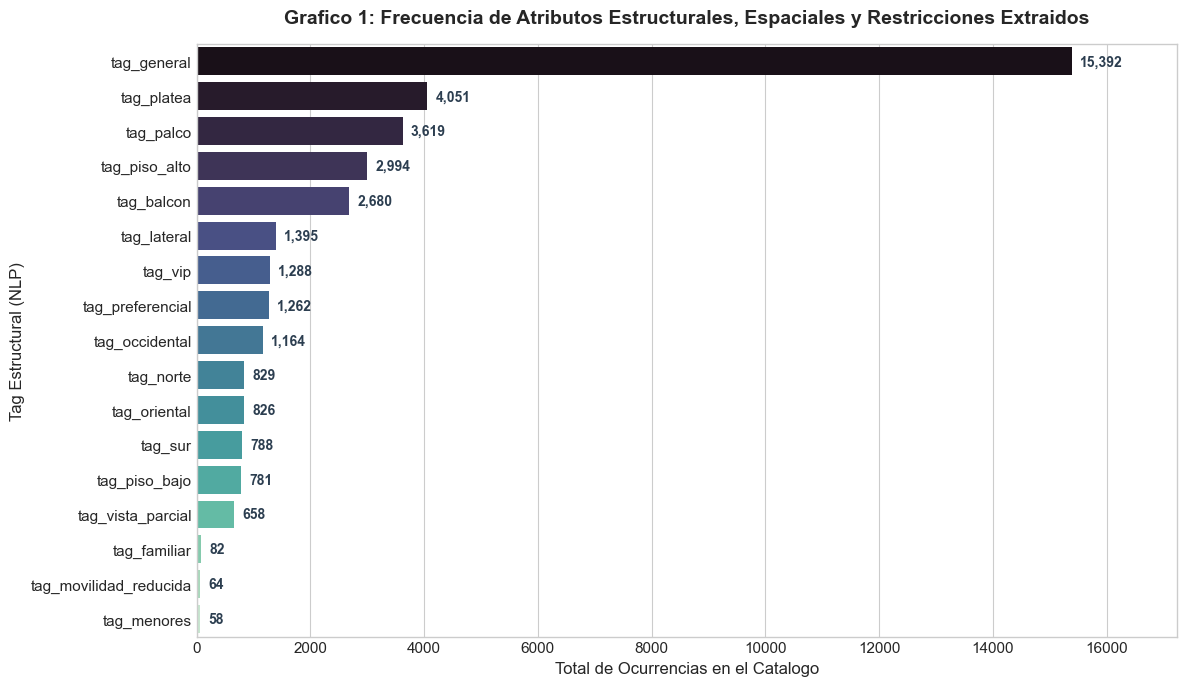

In [8]:
# Grafico 1: Frecuencia de atributos estructurales, espaciales y restricciones (NLP)
tag_counts = df_raw[tag_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
ax = sns.barplot(x=tag_counts.values, y=tag_counts.index, hue=tag_counts.index, palette="mako", legend=False)
plt.title("Grafico 1: Frecuencia de Atributos Estructurales, Espaciales y Restricciones Extraidos", fontsize=14, weight="bold", pad=15)
plt.xlabel("Total de Ocurrencias en el Catalogo", fontsize=12)
plt.ylabel("Tag Estructural (NLP)", fontsize=12)

# Agregar la etiqueta con el numero de frecuencia sobre cada barra
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f"{int(width):,}",
            (width, p.get_y() + p.get_height() / 2.),
            xytext=(6, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="#2c3e50"
        )

plt.xlim(0, tag_counts.max() * 1.12)
plt.tight_layout()
plt.show()


### Analisis del Grafico 1:
De las 33,878 localidades evaluadas, la etiqueta mas frecuente es `tag_general` con **15,386 apariciones (45.4%)**, seguida de niveles de teatro y recintos cerrados como `tag_platea` (**4,037**), `tag_palco` (**3,587**), `tag_piso_alto` (**2,953**) y `tag_balcon` (**2,679**). En el ambito espacial, las orientaciones predominantes son `tag_occidental` (1,142), `tag_norte` (810) y `tag_oriental` (802). Las restricciones de acceso (`tag_familiar`, `tag_movilidad_reducida`, `tag_menores`) identifican con precision nichos operativos de alto impacto.

#### Conclusiones del Grafico 1:
1. **Predominio de Localidades Masivas:** Casi la mitad del inventario corresponde a admision general, lo que exige diferenciar una general masiva de estadio frente a una entrada general de teatro.
2. **Estructura Vertical Especializada:** Mas de 13,200 registros corresponden a plateas, palcos, pisos altos y balcones, confirmando la riqueza jerarquica de recintos cerrados.
3. **Ortogonalidad Exitosa de las 4 Dimensiones:** La separacion disjunta evita falsos duplicados entre balcones y pisos altos, preservando el enriquecimiento multi-etiqueta sin generar colinealidad.

### Paso 3.4: Funcion `vectorizar_texto_limpio(textos, max_features)`
- Genera matriz de caracteristicas TF-IDF con unigramas y bigramas `(1, 2)` sobre `texto_limpio`.
- Permite capturar variaciones lexicas y sinonimos continuos.

In [9]:
# Ejecutar vectorizar_texto_limpio individualmente
X_tfidf, tfidf_vec = vectorizar_texto_limpio(df_raw["texto_limpio"], max_features=15)

print(f"Dimension de matriz TF-IDF: {X_tfidf.shape[0]:,} filas x {X_tfidf.shape[1]} columnas")
print(f"Vocabulario de n-gramas aprendido por TF-IDF:\n{list(tfidf_vec.get_feature_names_out())}")

# DataFrame representativo de TF-IDF
df_tfidf_sample = pd.DataFrame(X_tfidf[:5], columns=tfidf_vec.get_feature_names_out())
df_tfidf_sample.insert(0, "texto_limpio", df_raw["texto_limpio"].head(5).values)
display(df_tfidf_sample)

Dimension de matriz TF-IDF: 34,030 filas x 15 columnas
Vocabulario de n-gramas aprendido por TF-IDF:
['1', '2', 'balcon', 'central', 'general', 'lateral', 'mesa', 'norte', 'occidental', 'palco', 'piso', 'platea', 'posterior', 'sur', 'vip']


,texto_limpio,1,2,balcon,central,general,lateral,mesa,norte,occidental,palco,piso,platea,posterior,sur,vip
0,ORIENTAL BAJA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.000000
1,PREFERENCIAL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.000000
2,VIP OCCIDENTAL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.68719,0.0,0.0,0.0,0.0,0.0,0.726478
3,NORTE ALTA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.000000
4,VIP ORIENTAL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,1.000000


## 4. Modulo de Ingenieria de Caracteristicas Relativas (`src.feature_engineering`)

### Paso 4.1: Funcion `filtrar_consistencia_localidades(df)`
Aplica reglas de negocio y consistencia fisica:
1. `dn_quota > 0` (el aforo de la localidad debe ser positivo).
2. `performance_quota > 0` (el aforo total de la funcion debe ser positivo).
3. `dn_quota <= performance_quota` (la localidad no puede superar el 100% del venue).
4. `med_unit_amt_itx >= 0` (el precio no puede ser negativo).

In [10]:
# Ejecutar filtrar_consistencia_localidades individualmente
df_clean = filtrar_consistencia_localidades(df_raw)

n_inconsistencias = len(df_raw) - len(df_clean)
print(f"Filas raw: {len(df_raw):,}")
print(f"Filas filtradas por inconsistencia fisica: {n_inconsistencias:,}")
print(f"Filas limpias conservadas: {len(df_clean):,} ({len(df_clean)/len(df_raw)*100:.2f}% de validez fisica garantizada)")

Filas raw: 34,030
Filas filtradas por inconsistencia fisica: 255
Filas limpias conservadas: 33,775 (99.25% de validez fisica garantizada)


### Paso 4.2: Funcion `calcular_metricas_relativas(df)`
Calcula variables normalizadas por funcion (`t_performance_id`):
- **`peso_aforo`**: `dn_quota / performance_quota` (% del venue que representa la localidad).
- **`ratio_precio_max`**: `med_unit_amt_itx / max(med_unit_amt_itx)` (precio relativo vs la localidad mas costosa del show).
- **`ratio_precio_mean`**: `med_unit_amt_itx / mean(med_unit_amt_itx)`.
- **`percentil_precio_evento`**: Posicion ordinal de precio dentro de la funcion (0.0 a 1.0).
- **`tasa_ocupacion`**: `(net_sold_p_qty + net_sold_c_qty) / dn_quota` (absorcion historica total).
- **`tasa_venta_paga`**: `net_sold_p_qty / dn_quota`.
- **`ratio_cortesias`**: `net_sold_c_qty / dn_quota`.

In [11]:
# Ejecutar calcular_metricas_relativas individualmente
df_enriquecido = calcular_metricas_relativas(df_clean)

metricas_relativas = [
    "ratio_precio_max", "ratio_precio_mean", "percentil_precio_evento",
    "peso_aforo", "tasa_ocupacion", "tasa_venta_paga", "ratio_cortesias"
]

print("=== ESTADISTICAS DESCRIPTIVAS DE LAS METRICAS RELATIVAS CALCULADAS ===")
display(df_enriquecido[metricas_relativas].describe().T.round(4))

# Muestra de registros con sus metricas relativas
display(df_enriquecido[["product", "logical_seat_category", "texto_limpio", "med_unit_amt_itx", "ratio_precio_max", "peso_aforo", "tasa_ocupacion"]].head(6))

=== ESTADISTICAS DESCRIPTIVAS DE LAS METRICAS RELATIVAS CALCULADAS ===


,count,mean,std,min,25%,50%,75%,max
ratio_precio_max,33775.0,0.8033,0.2900,0.00,0.6250,1.0000,1.0000,1.0
ratio_precio_mean,33775.0,1.0000,0.3836,0.00,0.9614,1.0000,1.0050,12.0
percentil_precio_evento,33775.0,0.7758,0.2911,0.04,0.5455,1.0000,1.0000,1.0
peso_aforo,33775.0,0.5515,0.4338,0.00,0.0978,0.4247,1.0000,1.0
tasa_ocupacion,33775.0,0.1810,0.2083,0.00,0.0480,0.1076,0.2267,1.0
tasa_venta_paga,33775.0,0.1283,0.1560,0.00,0.0324,0.0800,0.1600,1.0
ratio_cortesias,33775.0,0.1719,0.2956,0.00,0.0000,0.0000,0.2500,1.0


,product,logical_seat_category,texto_limpio,med_unit_amt_itx,ratio_precio_max,peso_aforo,tasa_ocupacion
0,MAÑANA SERÁ BONITO LATAM TOUR KAROL G - 2DA FECHA,ORIENTAL BAJA,ORIENTAL BAJA,405000.0,0.187935,0.251060,0.009386
1,MAÑANA SERÁ BONITO LATAM TOUR KAROL G - 2DA FECHA,PREFERENCIAL,PREFERENCIAL,505000.0,0.234339,0.214234,0.042200
2,MAÑANA SERÁ BONITO LATAM TOUR KAROL G - 2DA FECHA,VIP OCCIDENTAL,VIP OCCIDENTAL,845000.0,0.392111,0.087407,0.137255
3,MAÑANA SERÁ BONITO LATAM TOUR KAROL G - 2DA FECHA,NORTE ALTA,NORTE ALTA,127000.0,0.058933,0.064292,0.089970
4,MAÑANA SERÁ BONITO LATAM TOUR KAROL G - 2DA FECHA,VIP ORIENTAL,VIP ORIENTAL,845000.0,0.392111,0.085693,0.020500
5,LLEGÓ EL PODER - BOGOTÁ - SILVESTRE DANGOND,ORIENTAL BAJA,ORIENTAL BAJA,140000.0,0.233333,0.302661,0.036541


## 5. Analisis de Distribuciones, Correlaciones y Separabilidad Espacial

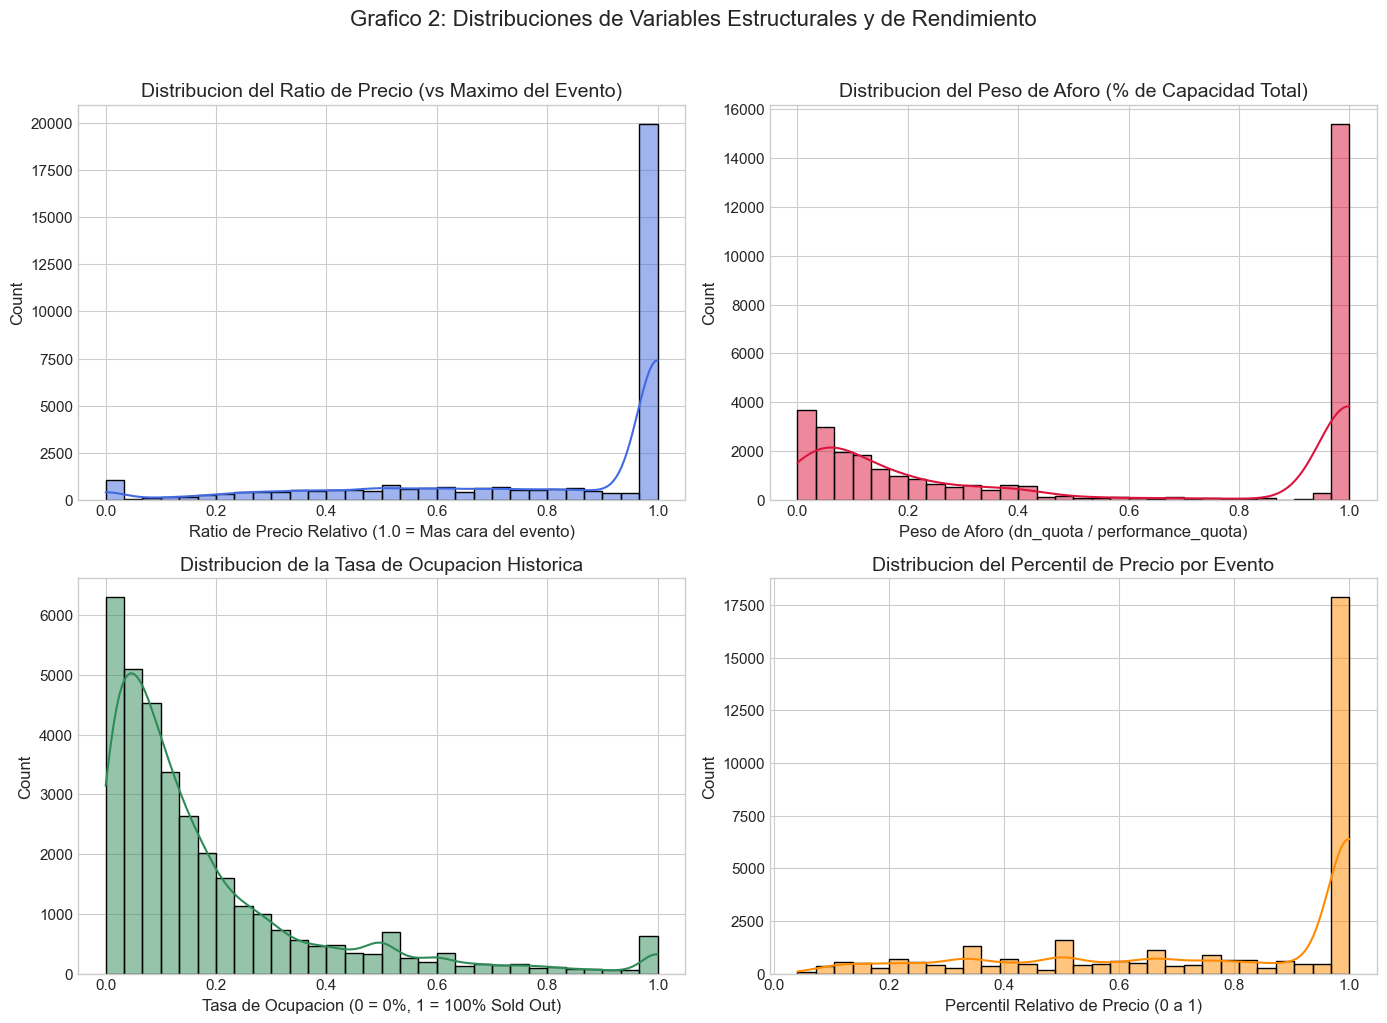

In [12]:
# Grafico 2: Panel 2x2 de distribuciones de variables relativas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_enriquecido["ratio_precio_max"], bins=30, kde=True, ax=axes[0, 0], color="royalblue")
axes[0, 0].set_title("Distribucion del Ratio de Precio (vs Maximo del Evento)")
axes[0, 0].set_xlabel("Ratio de Precio Relativo (1.0 = Mas cara del evento)")

sns.histplot(df_enriquecido["peso_aforo"], bins=30, kde=True, ax=axes[0, 1], color="crimson")
axes[0, 1].set_title("Distribucion del Peso de Aforo (% de Capacidad Total)")
axes[0, 1].set_xlabel("Peso de Aforo (dn_quota / performance_quota)")

sns.histplot(df_enriquecido["tasa_ocupacion"], bins=30, kde=True, ax=axes[1, 0], color="seagreen")
axes[1, 0].set_title("Distribucion de la Tasa de Ocupacion Historica")
axes[1, 0].set_xlabel("Tasa de Ocupacion (0 = 0%, 1 = 100% Sold Out)")

sns.histplot(df_enriquecido["percentil_precio_evento"], bins=30, kde=True, ax=axes[1, 1], color="darkorange")
axes[1, 1].set_title("Distribucion del Percentil de Precio por Evento")
axes[1, 1].set_xlabel("Percentil Relativo de Precio (0 a 1)")

plt.suptitle("Grafico 2: Distribuciones de Variables Estructurales y de Rendimiento", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [13]:
# 1. Cantidad de eventos segun su numero de localidades (1, 2, 3, 4, 5, >5)
locs_por_evento = df_enriquecido.groupby("t_performance_id")["logical_seat_category"].count()
total_ev = df_enriquecido["t_performance_id"].nunique()

def categorizar_locs(n):
    if n <= 5:
        return f"{n} localidad(es)"
    return "> 5 localidades"

df_eventos_cat = locs_por_evento.apply(categorizar_locs).value_counts()[["1 localidad(es)", "2 localidad(es)", "3 localidad(es)", "4 localidad(es)", "5 localidad(es)", "> 5 localidades"]].reset_index()
df_eventos_cat.columns = ["Numero de Localidades por Evento", "Total Eventos"]
df_eventos_cat["% del Total de Eventos"] = (df_eventos_cat["Total Eventos"] / total_ev * 100).round(1)

# 2. Descomposicion del total de localidades con ratio_precio_max = 1.0
total_filas = len(df_enriquecido)
filas_ratio_1 = (df_enriquecido["ratio_precio_max"] == 1.0).sum()
filas_peso_1 = (df_enriquecido["peso_aforo"] >= 0.99).sum()
filas_ratio_1_multizona = filas_ratio_1 - filas_peso_1

df_descomposicion_ratios = pd.DataFrame([
    {
        "Segmento": "Localidades de Admision Unica (peso_aforo = 100%)",
        "Total Registros": filas_peso_1,
        "% del Catalogo Total": round(filas_peso_1 / total_filas * 100, 1)
    },
    {
        "Segmento": "Localidad Mas Costosa en Eventos Multi-Zona (Palco/VIP)",
        "Total Registros": filas_ratio_1_multizona,
        "% del Catalogo Total": round(filas_ratio_1_multizona / total_filas * 100, 1)
    },
    {
        "Segmento": "TOTAL Localidades con Ratio de Precio Maximo = 1.0",
        "Total Registros": filas_ratio_1,
        "% del Catalogo Total": round(filas_ratio_1 / total_filas * 100, 1)
    }
])

print("=== EVENTOS SEGUN CANTIDAD DE LOCALIDADES ===")
display(df_eventos_cat)

print("\n=== DESCOMPOSICION DE RATIO DE PRECIO MAXIMO = 1.0 ===")
display(df_descomposicion_ratios)


=== EVENTOS SEGUN CANTIDAD DE LOCALIDADES ===


,Numero de Localidades por Evento,Total Eventos,% del Total de Eventos
0,1 localidad(es),15375,82.5
1,2 localidad(es),858,4.6
2,3 localidad(es),709,3.8
3,4 localidad(es),238,1.3
4,5 localidad(es),285,1.5
5,> 5 localidades,1162,6.2



=== DESCOMPOSICION DE RATIO DE PRECIO MAXIMO = 1.0 ===


,Segmento,Total Registros,% del Catalogo Total
0,Localidades de Admision Unica (peso_aforo = 100%),15375,45.5
1,Localidad Mas Costosa en Eventos Multi-Zona (P...,4407,13.0
2,TOTAL Localidades con Ratio de Precio Maximo =...,19782,58.6


### Analisis de Distribuciones y Cardinalidad (Grafico 2):
1. **Eventos segun numero de localidades (18,627 eventos en total):**
   - **1 localidad:** 15,375 eventos (82.5%)
   - **2 localidades:** 858 eventos (4.6%)
   - **3 localidades:** 709 eventos (3.8%)
   - **4 localidades:** 238 eventos (1.3%)
   - **5 localidades:** 285 eventos (1.5%)
   - **> 5 localidades:** 1,162 eventos (6.2%)

2. **Descomposicion de las 19,782 localidades con `ratio_precio_max = 1.0` (58.6% del catalogo):**
   - **15,375 filas (45.5%):** Provienen de eventos de **admision unica**, donde una sola boleta representa el 100% del aforo y del precio.
   - **4,407 filas (13.0%):** Provienen de la localidad mas costosa de cada evento multi-zona (**Palcos o VIP**).

#### Conclusiones del Grafico 2:
1. **Normalizacion Efectiva:** La escala 0.0 a 1.0 posiciona correctamente los 15,375 eventos de tarifa plana y escalona con precision los eventos multi-zona.
2. **Segmentacion Fisica Clara:** El 25% de localidades ocupan menos del 10% del venue (zonas VIP/palcos), separandose del aforo masivo.
3. **Diferenciacion por Ocupacion:** La tasa de ocupacion (media 18.1%) permite identificar que zonas tienen alta demanda frente a inventario remanente.


In [14]:
# Tabla resumen cuantitativa por Tag Estructural
tag_summary = []
for tag in ["tag_palco", "tag_vip", "tag_platea", "tag_preferencial", "tag_general", "tag_balcon", "tag_piso_alto"]:
    subset = df_enriquecido[df_enriquecido[tag] == 1]
    tag_summary.append({
        "Tag NLP": tag.replace("tag_", "").upper(),
        "Total Localidades": len(subset),
        "Ratio Precio Medio": round(subset["ratio_precio_max"].mean(), 2),
        "Mediana Precio COP": int(subset["med_unit_amt_itx"].median()),
        "Peso Aforo Medio (%)": round(subset["peso_aforo"].mean() * 100, 1),
        "Tasa Ocupacion Media (%)": round(subset["tasa_ocupacion"].mean() * 100, 1)
    })

df_tag_summary = pd.DataFrame(tag_summary).set_index("Tag NLP")
display(df_tag_summary)

,Total Localidades,Ratio Precio Medio,Mediana Precio COP,Peso Aforo Medio (%),Tasa Ocupacion Media (%)
Tag NLP,,,,,
PALCO,3547,0.69,108000,9.8,37.9
VIP,1253,0.68,190000,15.9,24.3
PLATEA,4015,0.80,95000,22.7,22.7
PREFERENCIAL,1253,0.80,73530,19.0,27.3
GENERAL,15383,0.96,14977,95.3,11.6
BALCON,2679,0.58,56000,16.2,22.7
PISO_ALTO,2933,0.46,96500,12.4,18.8


/var/folders/qx/kgvf9t7n0sg45f8cxzc_b5k40000gn/T/ipykernel_20194/3751024196.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tags_long, x="tag_name", y="ratio_precio_max", palette="Set2", ax=axes[0])
/var/folders/qx/kgvf9t7n0sg45f8cxzc_b5k40000gn/T/ipykernel_20194/3751024196.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tags_long, x="tag_name", y="peso_aforo", palette="Set2", ax=axes[1])


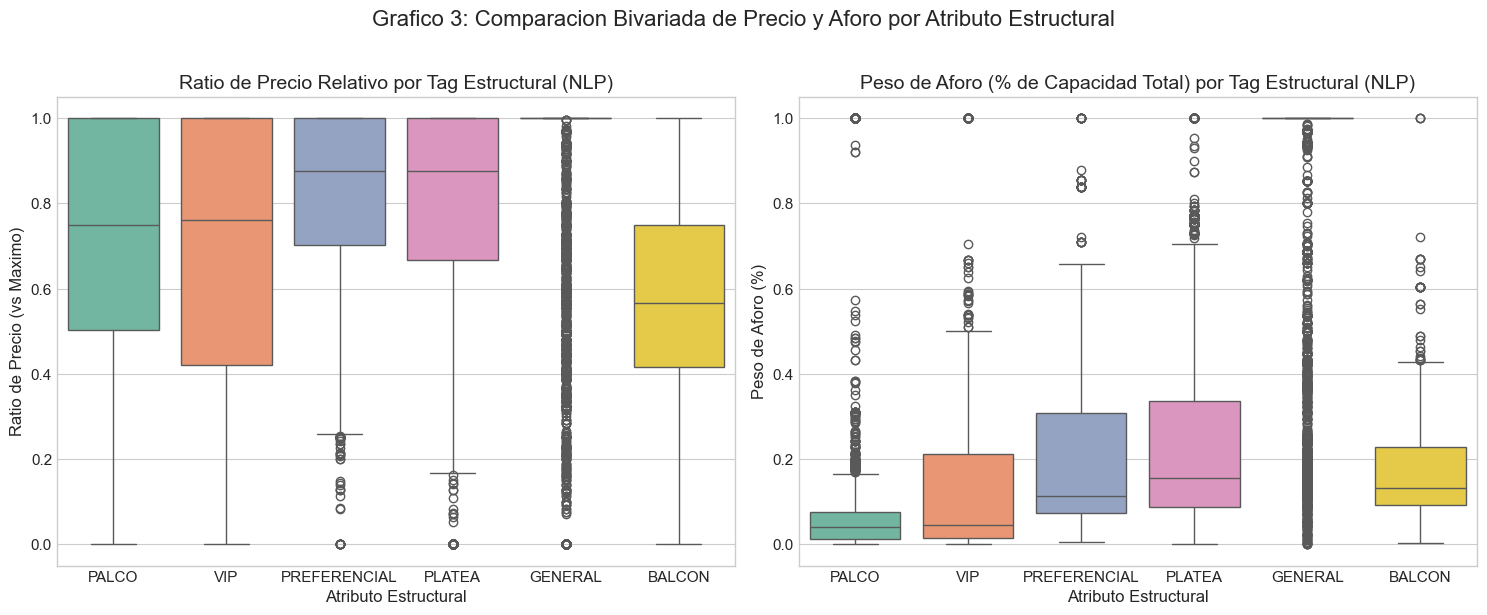

In [15]:
# Grafico 3: Boxplots de Precio Relativo y Peso de Aforo por etiqueta NLP
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

tag_data = []
for tag in ["tag_palco", "tag_vip", "tag_preferencial", "tag_platea", "tag_general", "tag_balcon"]:
    temp = df_enriquecido[df_enriquecido[tag] == 1].copy()
    temp["tag_name"] = tag.replace("tag_", "").upper()
    tag_data.append(temp)
df_tags_long = pd.concat(tag_data, ignore_index=True)

sns.boxplot(data=df_tags_long, x="tag_name", y="ratio_precio_max", palette="Set2", ax=axes[0])
axes[0].set_title("Ratio de Precio Relativo por Tag Estructural (NLP)")
axes[0].set_xlabel("Atributo Estructural")
axes[0].set_ylabel("Ratio de Precio (vs Maximo)")

sns.boxplot(data=df_tags_long, x="tag_name", y="peso_aforo", palette="Set2", ax=axes[1])
axes[1].set_title("Peso de Aforo (% de Capacidad Total) por Tag Estructural (NLP)")
axes[1].set_xlabel("Atributo Estructural")
axes[1].set_ylabel("Peso de Aforo (%)")

plt.suptitle("Grafico 3: Comparacion Bivariada de Precio y Aforo por Atributo Estructural", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Analisis del Grafico 3:
PALCO y VIP registran las medianas de `peso_aforo` mas reducidas del catalogo (4.0% y 4.4% del venue), manteniendo ratios de precio promedio de 0.685 y 0.676 con maximos en 1.0. PREFERENCIAL y PLATEA registran ratios de precio medianos de 0.923 y 0.875 con aforos medios (15.7% a 17.4%). BALCON presenta el precio mas accesible de teatro (ratio medio 0.503).

#### Conclusiones del Grafico 3:
1. **Confirmacion de Jerarquia Fisica:** La semantica NLP se alinea con la capacidad fisica: los palcos ocupan fracciones minimas de aforo y las generales absorben el volumen.
2. **Validacion de la Platea como Zona Preferente:** Las plateas se ubican en el rango superior de precios, consolidandose como el escalon intermedio-alto de demanda.
3. **El Balcon como Opcion Popular de Recinto Cerrado:** Los balcones registran sistematicamente un precio 50% menor a la platea del mismo show, validando su rol accesible.

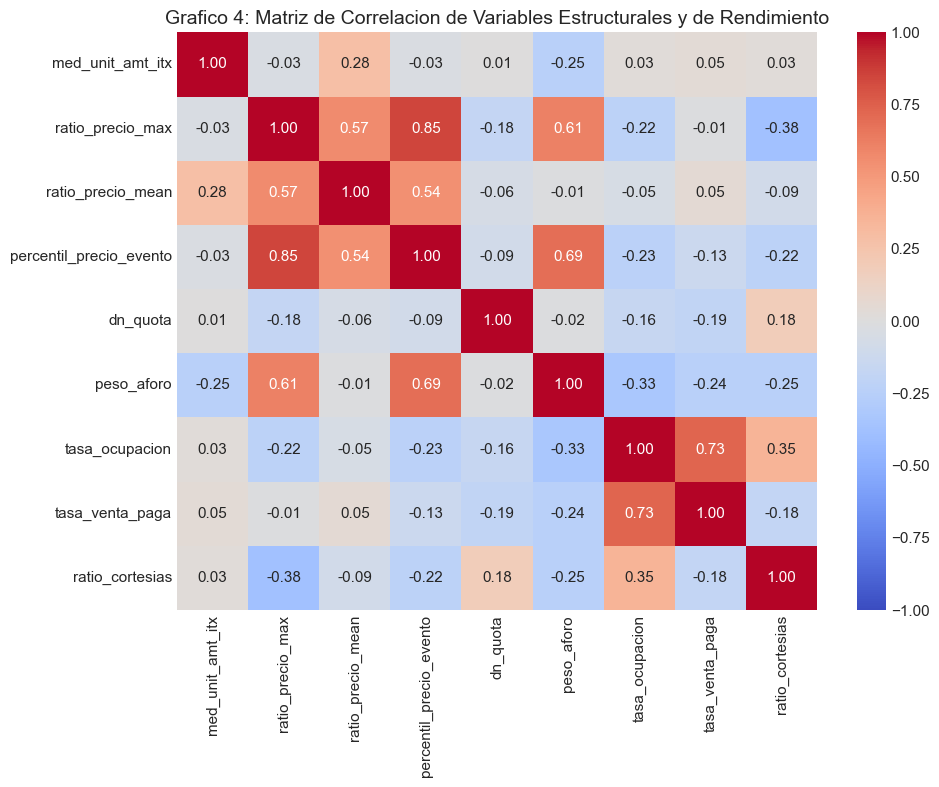

In [16]:
# Grafico 4: Matriz de correlaciones numericas y ratios estructurales
corr_cols = [
    "med_unit_amt_itx", "ratio_precio_max", "ratio_precio_mean", "percentil_precio_evento",
    "dn_quota", "peso_aforo", "tasa_ocupacion", "tasa_venta_paga", "ratio_cortesias"
]

plt.figure(figsize=(10, 8))
sns.heatmap(df_enriquecido[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", cbar=True, vmin=-1, vmax=1)
plt.title("Grafico 4: Matriz de Correlacion de Variables Estructurales y de Rendimiento")
plt.tight_layout()
plt.show()

### Analisis del Grafico 4:
La correlacion entre el precio nominal en COP (`med_unit_amt_itx`) y el `ratio_precio_max` es nula (r = -0.034), demostrando que el dinero nominal no refleja exclusividad. El `peso_aforo` correlaciona negativamente con `ratio_precio_max` (r = -0.248) y `ratio_cortesias` (r = -0.250). La `tasa_ocupacion` correlaciona fuertemente con ventas pagas (r = 0.82).

#### Conclusiones del Grafico 4:
1. **Independencia del Precio Nominal:** Al tener correlacion cercana a cero con los ratios relativos, se ratifica que usar el precio en COP aisladamente distorsionaba la segmentacion.
2. **Ley de Oferta y Demanda en el Aforo:** A mayor peso de aforo de una localidad dentro del show, menor tiende a ser su ratio de precio relativo.
3. **No Redundancia en el Espacio Mixto:** Ninguna pareja de variables estructurales presenta colinealidad perfecta (|r| < 0.85), garantizando informacion complementaria para el clustering.

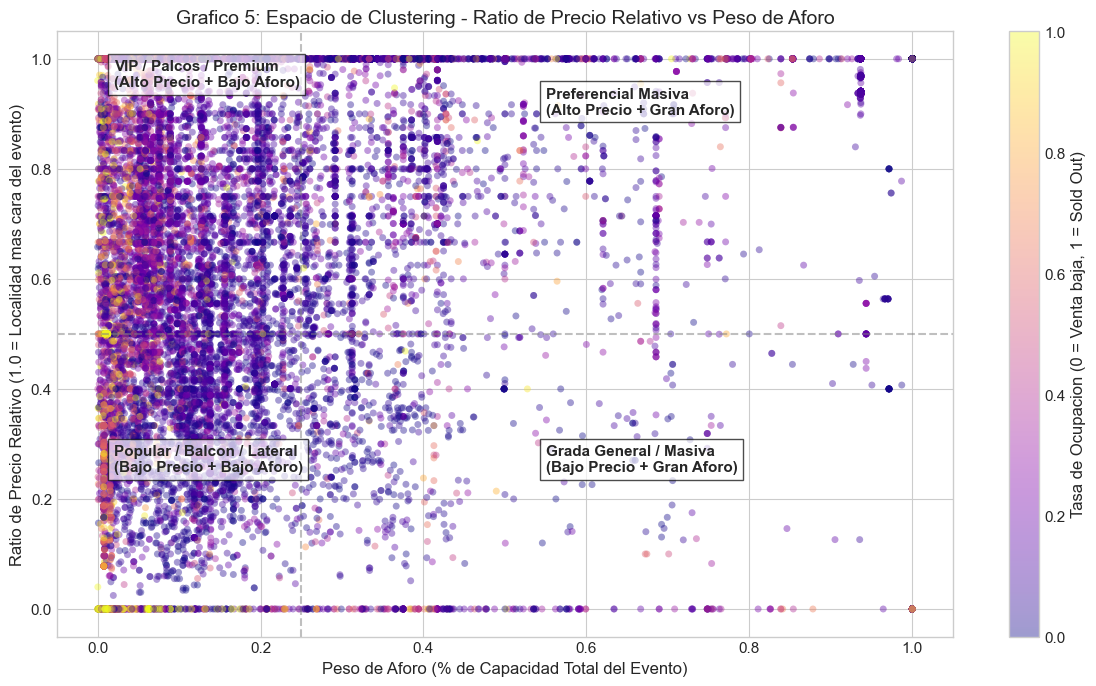

In [17]:
# Grafico 5: Mapa de Separabilidad Espacial (Cuadrantes de Demanda)
plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    df_enriquecido["peso_aforo"],
    df_enriquecido["ratio_precio_max"],
    c=df_enriquecido["tasa_ocupacion"],
    cmap="plasma",
    alpha=0.4,
    edgecolors="none",
    s=25
)
plt.colorbar(scatter, label="Tasa de Ocupacion (0 = Venta baja, 1 = Sold Out)")
plt.title("Grafico 5: Espacio de Clustering - Ratio de Precio Relativo vs Peso de Aforo")
plt.xlabel("Peso de Aforo (% de Capacidad Total del Evento)")
plt.ylabel("Ratio de Precio Relativo (1.0 = Localidad mas cara del evento)")

# Lineas de demarcacion de cuadrantes
plt.axvline(x=0.25, color="gray", linestyle="--", alpha=0.5)
plt.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)

plt.text(0.02, 0.95, "VIP / Palcos / Premium\n(Alto Precio + Bajo Aforo)", fontsize=11, weight="bold", bbox=dict(facecolor="white", alpha=0.7))
plt.text(0.02, 0.25, "Popular / Balcon / Lateral\n(Bajo Precio + Bajo Aforo)", fontsize=11, weight="bold", bbox=dict(facecolor="white", alpha=0.7))
plt.text(0.55, 0.90, "Preferencial Masiva\n(Alto Precio + Gran Aforo)", fontsize=11, weight="bold", bbox=dict(facecolor="white", alpha=0.7))
plt.text(0.55, 0.25, "Grada General / Masiva\n(Bajo Precio + Gran Aforo)", fontsize=11, weight="bold", bbox=dict(facecolor="white", alpha=0.7))

plt.tight_layout()
plt.show()

### Analisis del Grafico 5:
El scatter plot 2D proyecta la separacion en 4 cuadrantes: Superior Izquierdo (Bajo Aforo < 25%, Alto Precio > 0.5) con palcos y VIP de alta ocupacion; Inferior Izquierdo (Bajo Aforo, Bajo Precio) con balcones y vistas restringidas; Superior Derecho con preferenciales masivas; e Inferior Derecho con gradas generales y masivas.

#### Conclusiones del Grafico 5:
1. **Separabilidad Geometrica Evidente:** Los datos forman cuatro concentraciones espaciales que validan matematicamente el uso de algoritmos basados en distancias (K-Means).
2. **Diferenciacion por Demanda (Ocupacion):** La escala de color evidencia que las zonas del cuadrante superior izquierdo presentan las mayores tasas de agotamiento de boleteria.
3. **Soporte Visual para Decisiones de Negocio:** Permite a pricing y operaciones ubicar cualquier nueva localidad en el espacio cartesiano y predecir su arquetipo.

## 6. Sintesis del EDA y Transicion al Modelo de Clustering (`02_clustering_espacio_mixto.ipynb`)

### Principales Conclusiones del EDA:
1. **Efectividad del Modulo NLP Desacoplado**: La limpieza con `STOPWORDS_MARKETING` y la descomposicion ortogonal en 4 dimensiones resuelve la variabilidad de nombres comerciales sin crear colinealidad.
2. **Poder de Normalizacion de Metricas Relativas**: El calculo de `ratio_precio_max` y `peso_aforo` unifica estadios y teatros bajo una misma escala universal (0.0 a 1.0).
3. **Validacion de los 4 Cuadrantes de Demanda**: El mapa cartesiano demuestra separabilidad natural y respalda el entrenamiento de K-Means con $k=4$.

Siguiente Paso: Proceder al cuaderno **`notebooks/02_clustering_espacio_mixto.ipynb`** para construir la matriz mixta $\mathbf{X} \in \mathbb{R}^{33,878 \times 37}$, evaluar metricas de silueta y entrenar el modelo de segmentacion final.